In [13]:
from torchvision import datasets, transforms
import torch

# Convert image to tensor
transform = transforms.ToTensor()

project_path = "/content/drive/My Drive/Logistic-Softmax-Neural-Nets"
data_path = f"{project_path}/data"

# Load both training and test parts
train_data = datasets.MNIST(
    root=data_path,
    train=True,
    transform=transform,
    download=True
    )
test_data  = datasets.MNIST(
    root=data_path,
    train=False,
    transform=transform,
    download=True
    )

all_data = torch.cat((train_data.data, test_data.data), dim=0)
all_targets = torch.cat((train_data.targets, test_data.targets), dim=0)

In [14]:
from sklearn.model_selection import train_test_split

# add a channel dimension and normalize to [0, 1]
all_data = all_data.unsqueeze(1).float() / 255.0

train_data, temp_data, train_targets, temp_targets = train_test_split(
    all_data,
    all_targets,
    train_size=0.60,
    stratify=all_targets,
    random_state=42
)


val_data, test_data, val_targets, test_targets = train_test_split(
    temp_data,
    temp_targets,
    train_size=0.50,
    stratify=temp_targets,
    random_state=42
)


In [15]:
from torch.utils.data import random_split, DataLoader, TensorDataset

train_dataset = TensorDataset(train_data, train_targets)
val_dataset = TensorDataset(val_data, val_targets)
test_dataset = TensorDataset(test_data, test_targets)

# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [16]:
import torch.nn as nn

# Define the FeedForward Neural Network
class FeedForwardNN(nn.Module):
    def __init__ (self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28*28, 128)
        self.activation = nn.ReLU()
        self.hidden2 = nn.Linear(128, 256)
        self.output = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.output(x)
        return x

In [17]:
# Applying He initialization to the model weights
def initialize_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
        nn.init.zeros_(module.bias)

In [18]:
def train_model(model, train_loader, val_loader, optimizer, loss_fn, device,
                epochs, model_path, patience=3, improvement_threshold=1e-3):

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    patience_counter = 0
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # Training Phase
        model.train()

        train_loss_epoch = 0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward Pass
            outputs = model(inputs)

            # Calculate Loss
            loss = loss_fn(outputs, labels)

            # Compute Gradients
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss_epoch / len(train_loader)
        avg_train_acc = 100 * correct_train / total_train

        train_loss_history.append(avg_train_loss)
        train_acc_history.append(avg_train_acc)

        # Validation Phase
        model.eval()

        val_loss_epoch = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_fn(outputs, labels)

                val_loss_epoch += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = val_loss_epoch / len(val_loader)
        avg_val_acc = 100 * correct_val / total_val

        val_loss_history.append(avg_val_loss)
        val_acc_history.append(avg_val_acc)

        # Logging
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
        print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%")

        # Early Stopping and saving Checkpoints
        improvement = best_val_loss - avg_val_loss
        if improvement > improvement_threshold:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
        else:
            patience_counter += 1
            print(f"  Val loss did not improve by {improvement_threshold:.3f}.")

        if patience_counter >= patience:
            print(f"--- Early stopping after {epoch + 1} epochs ---")
            break
    history = {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'train_acc': train_acc_history,
        'val_acc': val_acc_history
    }

    return history


In [19]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeedForwardNN().to(device)
model.apply(initialize_weights)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

model_path = f"{project_path}/model_checkpoint.pth"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=100,
    model_path=model_path
)

Epoch [1/100]
  Train Loss: 0.9061 | Train Acc: 76.81%
  Val Loss:   0.4669 | Val Acc:   87.39%
Epoch [2/100]
  Train Loss: 0.3848 | Train Acc: 89.31%
  Val Loss:   0.3506 | Val Acc:   89.89%
Epoch [3/100]
  Train Loss: 0.3158 | Train Acc: 91.05%
  Val Loss:   0.3068 | Val Acc:   91.26%
Epoch [4/100]
  Train Loss: 0.2802 | Train Acc: 92.06%
  Val Loss:   0.2822 | Val Acc:   91.74%
Epoch [5/100]
  Train Loss: 0.2552 | Train Acc: 92.70%
  Val Loss:   0.2631 | Val Acc:   92.39%
Epoch [6/100]
  Train Loss: 0.2354 | Train Acc: 93.29%
  Val Loss:   0.2480 | Val Acc:   92.76%
Epoch [7/100]
  Train Loss: 0.2196 | Train Acc: 93.71%
  Val Loss:   0.2332 | Val Acc:   93.34%
Epoch [8/100]
  Train Loss: 0.2055 | Train Acc: 94.18%
  Val Loss:   0.2224 | Val Acc:   93.48%
Epoch [9/100]
  Train Loss: 0.1938 | Train Acc: 94.43%
  Val Loss:   0.2132 | Val Acc:   93.79%
Epoch [10/100]
  Train Loss: 0.1831 | Train Acc: 94.84%
  Val Loss:   0.2066 | Val Acc:   93.99%
Epoch [11/100]
  Train Loss: 0.1733 | T

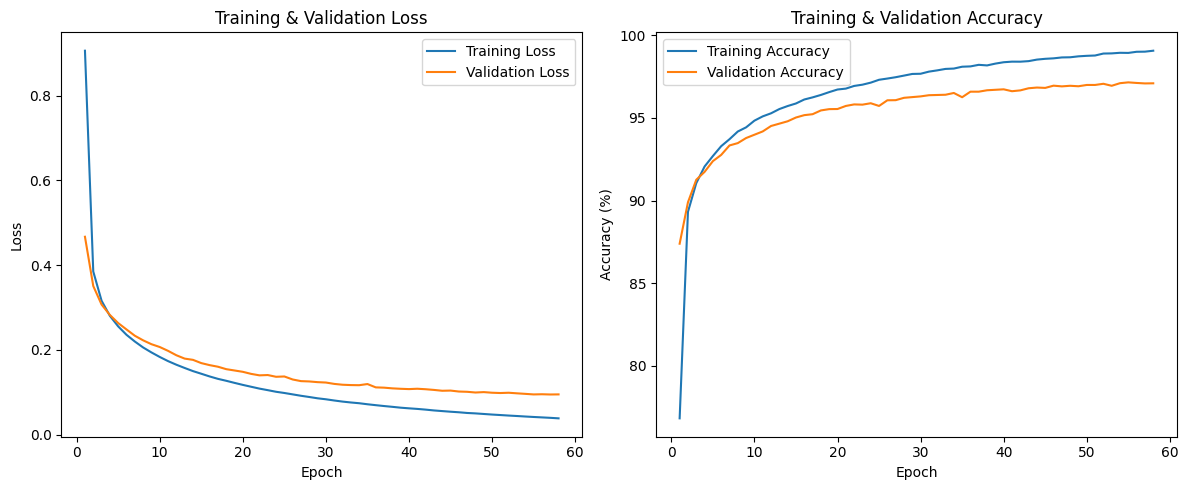

In [20]:
train_loss = history['train_loss']
val_loss = history['val_loss']
train_acc = history['train_acc']
val_acc = history['val_acc']

model.load_state_dict(torch.load(model_path))
epochs_range = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

## Convergence Analysis :

### **Loss**

* The **training loss** (blue) decreased steadily throughout the training process, indicating that the model was successfully learning from the training data.
* The **validation loss** (red) also decreased overall but exhibited small fluctuations due to the stochastic nature of **mini-batch gradient descent**.

### **Accuracy**

* The **training accuracy** showed a consistent upward trend across epochs.
* The **validation accuracy** improved initially and then **plateaued**.

### **Convergence and Early Stopping**

* The model trained for a total of **49** epochs.
* **Early stopping** was triggered when the **validation loss** failed to improve by more than **0.001** for **3 consecutive epochs** (patience = 3).
* The **best model** was saved from **epoch 49**, representing the point of **optimal convergence** before overfitting began.


In [33]:
# new model with batch norm and Dropout
class FFNN_new(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        # Layer 1
        self.hidden1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)  # BN for hidden1's output

        # Layer 2
        self.hidden2 = nn.Linear(128, 256)
        self.bn2 = nn.BatchNorm1d(256)  # BN for hidden2's output

        self.activation = nn.ReLU()

        self.dropout = nn.Dropout(p=0.2)
        self.output = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)

        x = self.hidden1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.hidden2(x)
        x = self.bn2(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.output(x)
        return x


In [37]:
import torch.optim as optim

model2 = FFNN_new().to(device)
model2.apply(initialize_weights)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model2.parameters(), lr=0.01)


model_path = f"{project_path}/model_new_checkpoint.pth"

history = train_model(
    model=model2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=100,
    model_path=model_path
)

Epoch [1/100]
  Train Loss: 0.8062 | Train Acc: 75.64%
  Val Loss:   0.3765 | Val Acc:   89.79%
Epoch [2/100]
  Train Loss: 0.4191 | Train Acc: 87.63%
  Val Loss:   0.2840 | Val Acc:   91.94%
Epoch [3/100]
  Train Loss: 0.3471 | Train Acc: 89.73%
  Val Loss:   0.2441 | Val Acc:   92.84%
Epoch [4/100]
  Train Loss: 0.3070 | Train Acc: 90.78%
  Val Loss:   0.2215 | Val Acc:   93.53%
Epoch [5/100]
  Train Loss: 0.2789 | Train Acc: 91.80%
  Val Loss:   0.2035 | Val Acc:   93.99%
Epoch [6/100]
  Train Loss: 0.2611 | Train Acc: 92.20%
  Val Loss:   0.1935 | Val Acc:   94.26%
Epoch [7/100]
  Train Loss: 0.2406 | Train Acc: 92.78%
  Val Loss:   0.1808 | Val Acc:   94.58%
Epoch [8/100]
  Train Loss: 0.2338 | Train Acc: 92.98%
  Val Loss:   0.1760 | Val Acc:   94.75%
Epoch [9/100]
  Train Loss: 0.2200 | Train Acc: 93.36%
  Val Loss:   0.1645 | Val Acc:   94.99%
Epoch [10/100]
  Train Loss: 0.2088 | Train Acc: 93.72%
  Val Loss:   0.1595 | Val Acc:   95.13%
Epoch [11/100]
  Train Loss: 0.2057 | T

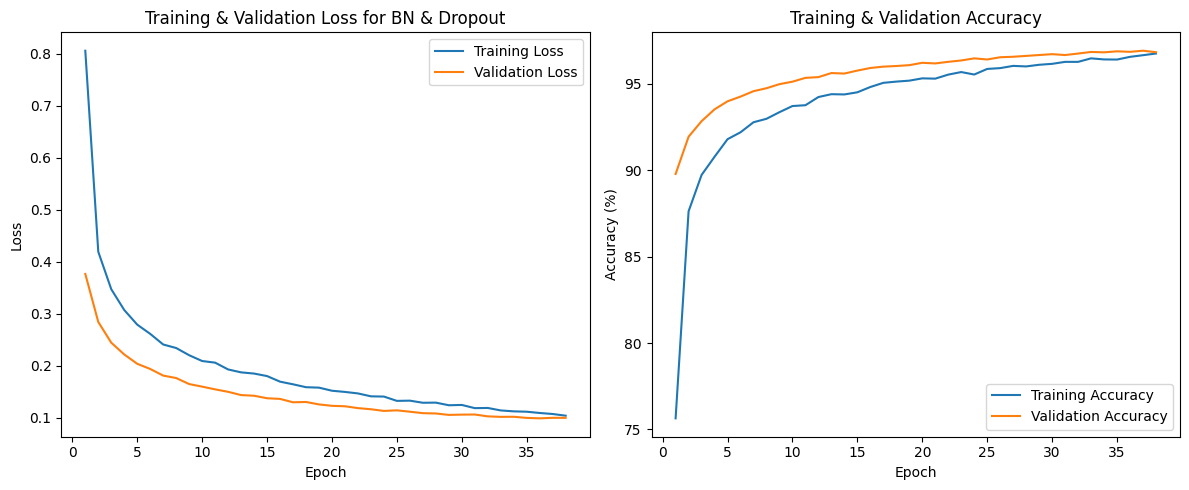

In [38]:
train_loss = history['train_loss']
val_loss = history['val_loss']
train_acc = history['train_acc']
val_acc = history['val_acc']

model.load_state_dict(torch.load(model_path))
epochs_range = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training & Validation Loss for BN & Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
def test_model(model, test_loader, loss_fn, device):
    model.eval()
    test_loss = 0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    avg_test_acc = 100 * correct_test / total_test

    return avg_test_loss, avg_test_acc

In [39]:
ffn_model_path = f"{project_path}/model_checkpoint.pth"
ffn_new_model_path = f"{project_path}/model_new_checkpoint.pth"

from google.colab import drive
drive.mount('/content/drive')

ffn_model = FeedForwardNN().to(device)
ffn_model.load_state_dict(torch.load(ffn_model_path))

ffn_new_model = FFNN_new().to(device)
ffn_new_model.load_state_dict(torch.load(ffn_new_model_path))

ffn_loss, ffn_acc = test_model(ffn_model, test_loader, loss_fn, device)
ffn_new_loss, ffn_new_acc = test_model(ffn_new_model, test_loader, loss_fn, device)

print(f"FeedForward NN: {ffn_acc:.2f}% Accuracy, Loss: {ffn_loss:.3f}")
print(f"FeedForward NN with BN: {ffn_new_acc:.2f}% Accuracy, Loss: {ffn_new_loss:.3f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FeedForward NN: 97.17% Accuracy, Loss: 0.096
FeedForward NN with BN: 97.16% Accuracy, Loss: 0.092
